In [2]:
import kagglehub

path = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Path to dataset files: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes


In [3]:
dataset_path = "/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data"

In [4]:
import os
classes = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        classes.append(folder)

print("Classes Found:")
print(classes)
print("Number of Classes:", len(classes))

Classes Found:
['labels', 'images', 'labels-YOLO']
Number of Classes: 3


In [5]:
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len(os.listdir(class_path))
    print(class_name, ":", num_images)

labels : 2009
images : 2009
labels-YOLO : 2009


Total Images: 2009


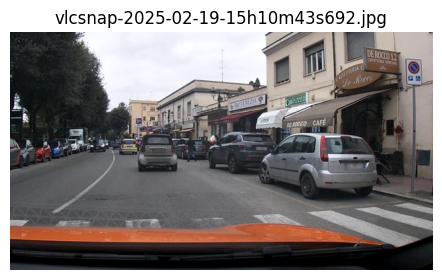

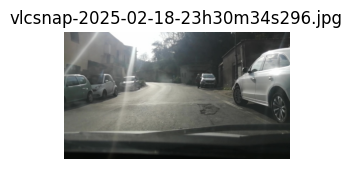

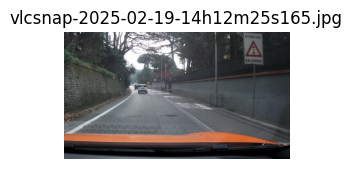

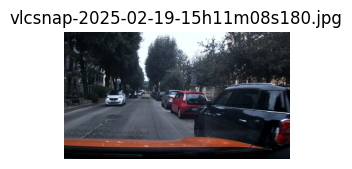

In [6]:
import os
import matplotlib.pyplot as plt

image_folder = os.path.join(dataset_path, "images")
image_files = os.listdir(image_folder)
print("Total Images:", len(image_files))

plt.figure(figsize=(12,8))
for i in range(4):
    image_path = os.path.join(
        image_folder,
        image_files[i]
    )
    img = plt.imread(image_path)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(image_files[i])
    plt.axis("off")
    plt.show()

In [7]:
label_folder = os.path.join(dataset_path, "labels")
label_files = os.listdir(label_folder)
print("Total Label Files:", len(label_files))

sample_label = os.path.join(
    label_folder,
        label_files[0]
        )
with open(sample_label, "r") as f:
    print(f.read())

Total Label Files: 2009
2 0.342187 0.558333 0.403125 0.558333 0.403125 0.591667 0.342187 0.591667
2 0.409375 0.561111 0.453125 0.561111 0.453125 0.594444 0.409375 0.594444



In [8]:
classes = os.listdir(dataset_path)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['COCO-conversion-script.py', 'labels', 'annotations_coco.json', 'README.md', 'YOLO-conversion-script.py', 'images', 'labels-YOLO']
Number of classes: 7


In [10]:
import os

label_folder = os.path.join(dataset_path, "labels")

class_ids = set()

for file in os.listdir(label_folder):

    label_path = os.path.join(label_folder, file)

    with open(label_path, "r") as f:

         lines = f.readlines()

         for line in lines:

              class_id = int(line.split()[0])

              class_ids.add(class_id)

print("Classes Found:", class_ids)

print("Number of Classes:", len(class_ids))


Classes Found: {0, 1, 2}
Number of Classes: 3


In [11]:
class_names = {
      0: "pothole",
          1: "crack",
              2: "manhole"
              }

print(class_names)


{0: 'pothole', 1: 'crack', 2: 'manhole'}


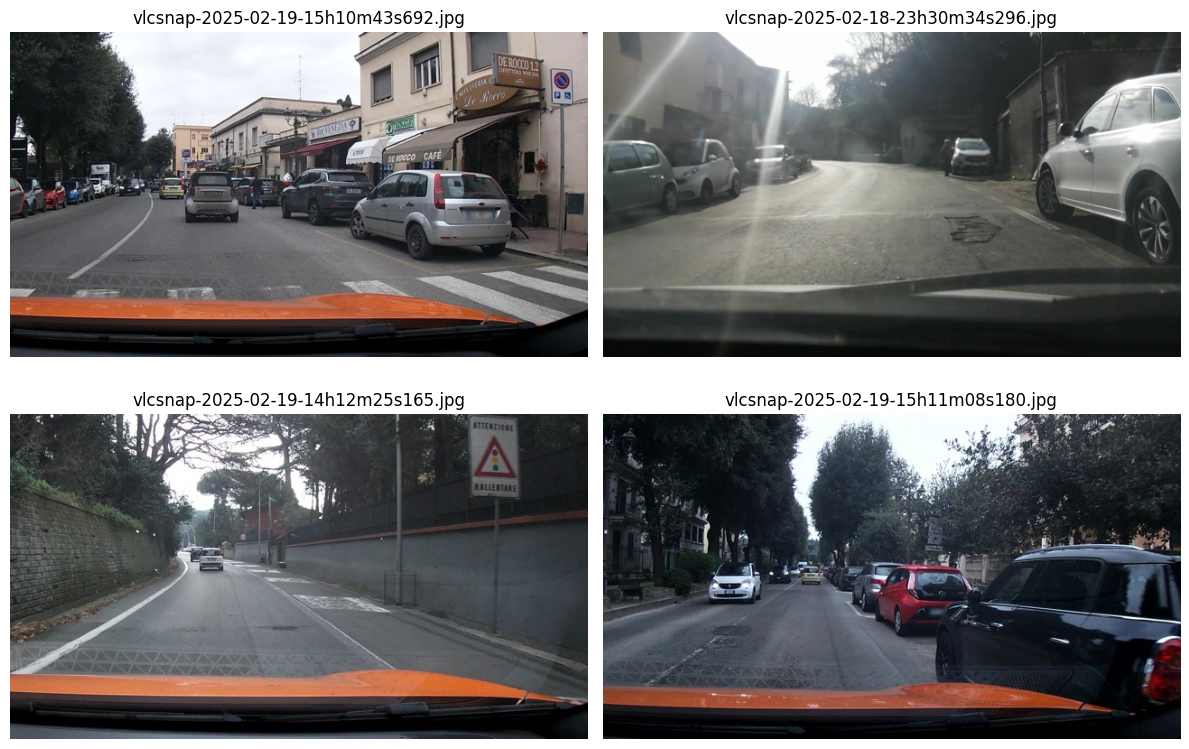

In [12]:
import matplotlib.pyplot as plt

image_folder = os.path.join(dataset_path, "images")

image_files = os.listdir(image_folder)

plt.figure(figsize=(12,8))

for i in range(4):

    img_path = os.path.join(image_folder, image_files[i])

    img = plt.imread(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(image_files[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [13]:
from PIL import Image

for i in range(5):

    img_path = os.path.join(image_folder, image_files[i])

    img = Image.open(img_path)

    print(image_files[i], ":", img.size)

vlcsnap-2025-02-19-15h10m43s692.jpg : (640, 360)
vlcsnap-2025-02-18-23h30m34s296.jpg : (640, 360)
vlcsnap-2025-02-19-14h12m25s165.jpg : (640, 360)
vlcsnap-2025-02-19-15h11m08s180.jpg : (640, 360)
vlcsnap-2025-02-18-23h15m30s977.jpg : (640, 360)


In [14]:
class_counts = {}

for class_id in class_ids:
    class_counts[class_id] = 0

for file in os.listdir(label_folder):

    label_path = os.path.join(label_folder, file)

    with open(label_path, "r") as f:

        lines = f.readlines()

        for line in lines:

            class_id = int(line.split()[0])

            class_counts[class_id] += 1

print(class_counts)

{0: 1261, 1: 2519, 2: 957}


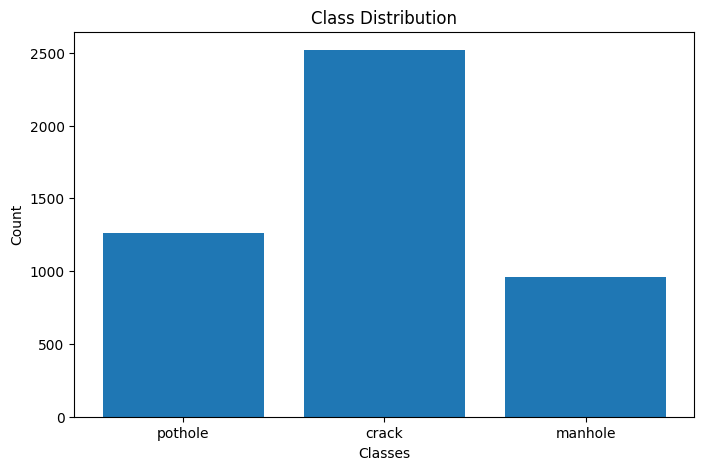

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    [class_names[i] for i in class_counts.keys()],
        class_counts.values()
        )

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Count")

plt.show()

In [16]:
import pandas as pd

data = []

for label_file in os.listdir(label_folder):

    label_path = os.path.join(label_folder, label_file)

    image_name = label_file.replace(".txt", ".jpg")

    image_path = os.path.join(image_folder, image_name)

    with open(label_path, "r") as f:

         lines = f.readlines()

         if len(lines) > 0:

              class_id = int(lines[0].split()[0])

              data.append([image_path, class_id])

df = pd.DataFrame(data, columns=["image_path", "label"])

df.head()

,image_path,label
0,/kaggle/input/road-damage-dataset-potholes-cra...,2
1,/kaggle/input/road-damage-dataset-potholes-cra...,2
2,/kaggle/input/road-damage-dataset-potholes-cra...,1
3,/kaggle/input/road-damage-dataset-potholes-cra...,0
4,/kaggle/input/road-damage-dataset-potholes-cra...,1


In [17]:
df["label_name"] = df["label"].map(class_names)

df.head()

,image_path,label,label_name
0,/kaggle/input/road-damage-dataset-potholes-cra...,2,manhole
1,/kaggle/input/road-damage-dataset-potholes-cra...,2,manhole
2,/kaggle/input/road-damage-dataset-potholes-cra...,1,crack
3,/kaggle/input/road-damage-dataset-potholes-cra...,0,pothole
4,/kaggle/input/road-damage-dataset-potholes-cra...,1,crack


In [18]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
        test_size=0.2,
            random_state=42,
                stratify=df["label"]
                )

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 1607
Test: 402


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(

    rescale=1./255,

        rotation_range=20,

            zoom_range=0.2,

                horizontal_flip=True,

                    brightness_range=[0.8,1.2]

                    )

test_datagen = ImageDataGenerator(
                        rescale=1./255
                        )

In [20]:
train_generator = train_datagen.flow_from_dataframe(

      train_df,

          x_col="image_path",

              y_col="label_name",

                  target_size=(IMG_SIZE, IMG_SIZE),

                      batch_size=BATCH_SIZE,

                          class_mode="categorical"

                          )


Found 1607 validated image filenames belonging to 3 classes.


In [21]:
test_generator = test_datagen.flow_from_dataframe(

      test_df,

          x_col="image_path",

              y_col="label_name",

                  target_size=(IMG_SIZE, IMG_SIZE),

                      batch_size=BATCH_SIZE,

                          class_mode="categorical",

                              shuffle=False


)

Found 402 validated image filenames belonging to 3 classes.


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# Block 1
model.add(
    Conv2D(
            32,
                    (3,3),
                            activation='relu',
                                    input_shape=(224,224,3)
                                        )
                                        )

model.add(MaxPooling2D(2,2))

                                        # Block 2
model.add(
                                            Conv2D(
                                                    64,
                                                            (3,3),
                                                                    activation='relu'
                                                                        )
                                                                        )

model.add(MaxPooling2D(2,2))

                                                                        # Block 3
model.add(
                                                                            Conv2D(
                                                                                    128,
                                                                                            (3,3),
                                                                                                    activation='relu'
                                                                                                        )
                                                                                                        )

model.add(MaxPooling2D(2,2))

                                                                                                        # Flatten
model.add(Flatten())

                                                                                                        # Dense
model.add(Dense(128, activation='relu'))

                                                                                                        # Dropout
model.add(Dropout(0.5))

                                                                                                        # Output
model.add(
                                                                                                            Dense(
                                                                                                                    len(class_names),
                                                                                                                            activation='softmax'
                                                                                                                                )
                                                                                                                                )

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(

      optimizer='adam',

          loss='categorical_crossentropy',

              metrics=['accuracy']


)

In [24]:
history = model.fit(

      train_generator,

          validation_data=test_generator,

              epochs=10


)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 55s 919ms/step - accuracy: 0.4736 - loss: 1.0963 - val_accuracy: 0.5000 - val_loss: 1.0289
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 30s 571ms/step - accuracy: 0.4978 - loss: 1.0442 - val_accuracy: 0.5000 - val_loss: 1.0336
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 42s 836ms/step - accuracy: 0.4984 - loss: 1.0306 - val_accuracy: 0.5000 - val_loss: 1.0052
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 714ms/step - accuracy: 0.4984 - loss: 1.0080 - val_accuracy: 0.5000 - val_loss: 0.9989
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 641ms/step - accuracy: 0.4972 - loss: 1.0091 - val_accuracy: 0.5000 - val_loss: 1.0033
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 38s 751ms/step - accuracy: 0.4966 - loss: 0.9984 - val_accuracy: 0.5000 - val_loss: 0.9948
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 606ms/step - accuracy: 0.4891 - loss: 0.9893 - val_accuracy: 0.5000 - val_loss: 1.0250
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 39s 768ms/step - accuracy: 0.5121 - loss: 0.9758 - val_accu

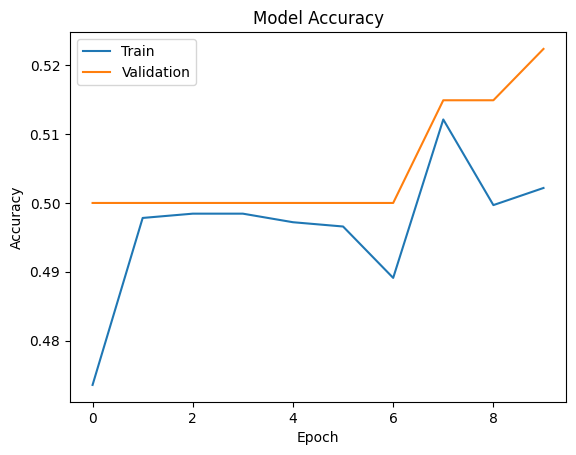

In [25]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [26]:
import numpy as np

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step


In [27]:
from sklearn.metrics import classification_report

print(

    classification_report(

            y_true,

                    y_pred,

                            target_names=test_generator.class_indices.keys()

                                )

                                )

              precision    recall  f1-score   support

       crack       0.54      0.87      0.67       201
     manhole       0.35      0.11      0.17       108
     pothole       0.50      0.25      0.33        93

    accuracy                           0.52       402
   macro avg       0.47      0.41      0.39       402
weighted avg       0.48      0.52      0.46       402



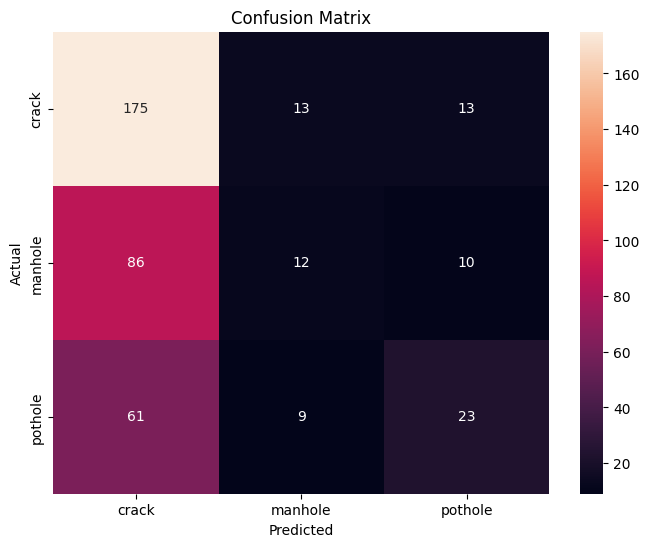

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    xticklabels=test_generator.class_indices.keys(),

    yticklabels=test_generator.class_indices.keys()

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [33]:
train_acc = history.history['accuracy'][-1]

val_acc = history.history['val_accuracy'][-1]

print("Training Accuracy :", round(train_acc * 100, 2), "%")

print("Validation Accuracy :", round(val_acc * 100, 2), "%")

Training Accuracy : 50.22 %
Validation Accuracy : 52.24 %


In [29]:
errors = np.where(y_pred != y_true)[0]

print("Wrong Predictions:", len(errors))

Wrong Predictions: 192


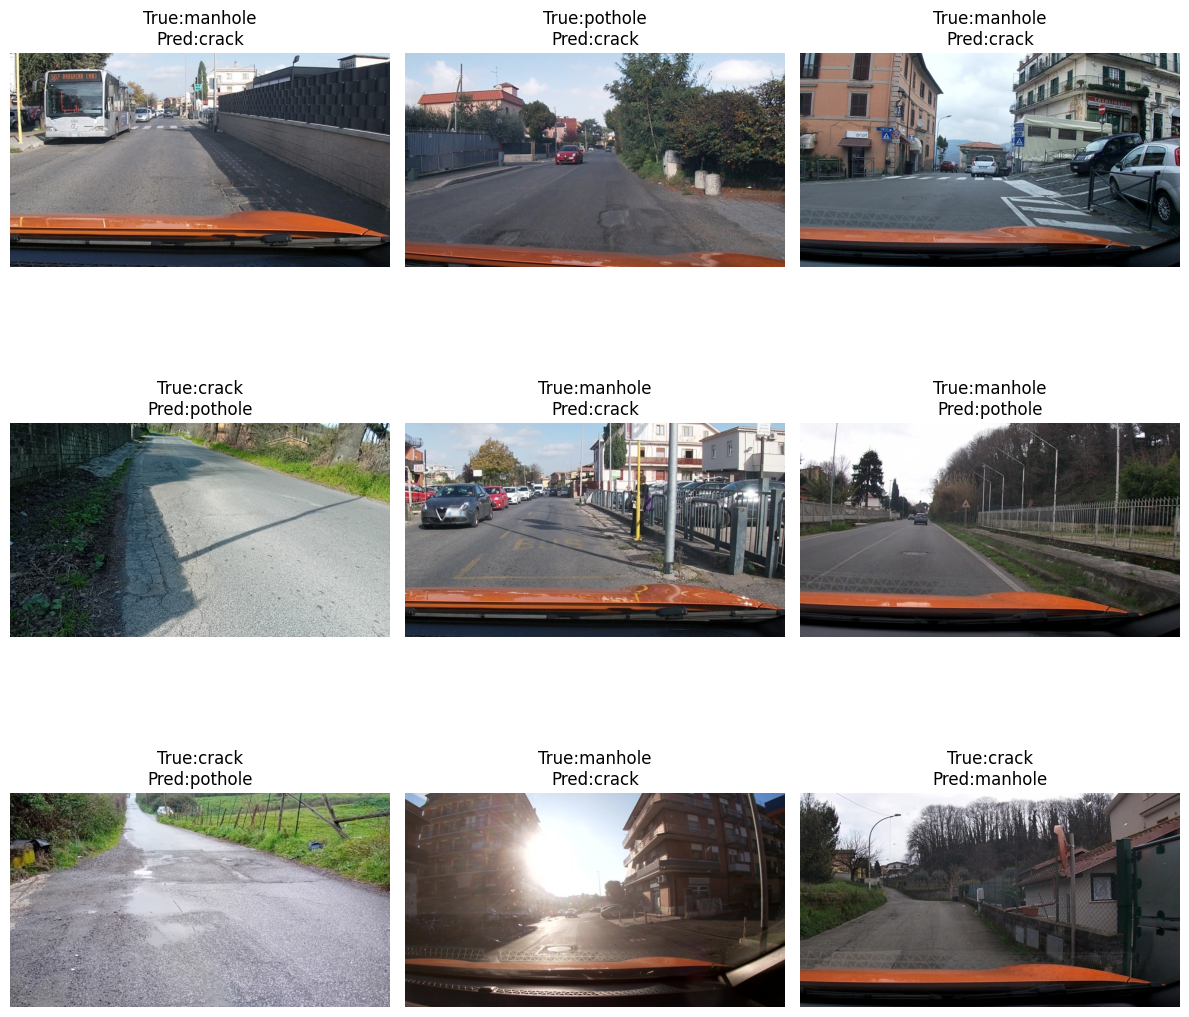

In [30]:
plt.figure(figsize=(12,12))

for i, idx in enumerate(errors[:9]):

    img_path = test_df.iloc[idx]["image_path"]

    img = plt.imread(img_path)

    true_label = test_df.iloc[idx]["label_name"]

    pred_label = list(
               test_generator.class_indices.keys()
    )[y_pred[idx]]

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
       f"True:{true_label}\nPred:{pred_label}"
                                                    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [61]:
from google.colab import files

uploaded = files.upload()

Saving road_pathole.jpg to road_pathole (5).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Class: pothole


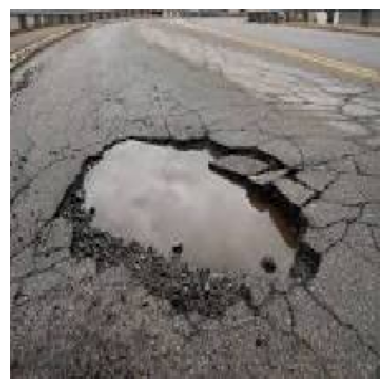

In [62]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(

    img_path,

        target_size=(224,224)

        )

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print(

     "Predicted Class:",

      class_names[predicted_class]

     )

plt.imshow(img)

plt.axis("off")

plt.show()

In [39]:
model.save("road_damage_model.h5")

In [41]:
model.save_weights("road_damage.weights.h5")

In [42]:
import json

with open("label_mapping.json", "w") as f:

    json.dump(class_names, f)

In [44]:
from google.colab import files

files.download("road_damage_model.h5")

files.download("road_damage.weights.h5")

files.download("label_mapping.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>